In [ ]:
import pandas as pd #for uploding the data
import numpy as np # mathematical
import re
import nltk
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
from collections import Counter
from wordcloud import WordCloud



In [ ]:
#required nltk files
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicom')
nltk.download('punkt_tab')
nltk.download('vader_lexicon')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Error loading vader_lexicom: Package 'vader_lexicom' not
[nltk_data]     found in index
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [ ]:
data = {
    "Review": [
        "The product quality is excellent and delivery was very fast.",
        "Very bad packaging and the item was damaged.",
        "Customer service was helpful and responsive.",
        "The delivery was delayed and support team did not respond.",
        "Amazing product. Worth the money.",
        "Poor quality product and terrible experience.",
        "Fast shipping and good packaging.",
        "The product stopped working after two days.",
        "Excellent service and great quality.",
        "Late delivery and bad customer support."
    ]
}

# Create DataFrame
df = pd.DataFrame(data)
df

,Review
0,The product quality is excellent and delivery ...
1,Very bad packaging and the item was damaged.
2,Customer service was helpful and responsive.
3,The delivery was delayed and support team did ...
4,Amazing product. Worth the money.
5,Poor quality product and terrible experience.
6,Fast shipping and good packaging.
7,The product stopped working after two days.
8,Excellent service and great quality.
9,Late delivery and bad customer support.


In [ ]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text=text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    words=word_tokenize(text)
    words = [word for word in words if word not in stop_words]

    cleaned_text=" ".join(words)

    return cleaned_text

df["cleaned_Review"]= df["Review"].apply(clean_text)
print("\n cleaned reviews")
print(df[[ 'Review','cleaned_Review']])


 cleaned reviews
                                              Review  \
0  The product quality is excellent and delivery ...   
1       Very bad packaging and the item was damaged.   
2       Customer service was helpful and responsive.   
3  The delivery was delayed and support team did ...   
4                  Amazing product. Worth the money.   
5      Poor quality product and terrible experience.   
6                  Fast shipping and good packaging.   
7        The product stopped working after two days.   
8               Excellent service and great quality.   
9            Late delivery and bad customer support.   

                             cleaned_Review  
0   product quality excellent delivery fast  
1                bad packaging item damaged  
2       customer service helpful responsive  
3     delivery delayed support team respond  
4               amazing product worth money  
5  poor quality product terrible experience  
6              fast shipping good packaging

In [ ]:
stop_words=set(stopwords.words('english'))
stop_words

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

Step 4: Sentiment Analysis

In [ ]:
sia=SentimentIntensityAnalyzer()
def analyze_sentiment(review):
    score=sia.polarity_scores(review)
    compound=score['compound']
    if compound >= 0.05:
        return 'Positive'
    elif compound <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'
df['Sentiment'] = df['cleaned_Review'].apply(analyze_sentiment)

print("\n Sentiment Analysis")
print(df[['Review', 'Sentiment']])


 Sentiment Analysis
                                              Review Sentiment
0  The product quality is excellent and delivery ...  Positive
1       Very bad packaging and the item was damaged.  Negative
2       Customer service was helpful and responsive.  Positive
3  The delivery was delayed and support team did ...  Positive
4                  Amazing product. Worth the money.  Positive
5      Poor quality product and terrible experience.  Negative
6                  Fast shipping and good packaging.  Positive
7        The product stopped working after two days.  Negative
8               Excellent service and great quality.  Positive
9            Late delivery and bad customer support.  Negative


step 5: common keywords


In [ ]:
all_words = ' '.join(df['cleaned_Review'])
word_list = all_words.split()

word_freq=Counter(word_list)
print("\n Top 10 Common keywords")
print(word_freq.most_common(10))


 Top 10 Common keywords
[('product', 4), ('quality', 3), ('delivery', 3), ('excellent', 2), ('fast', 2), ('bad', 2), ('packaging', 2), ('customer', 2), ('service', 2), ('support', 2)]


**step 6: Identify common complaints**

>



In [ ]:
negative_reviews = df[df['Sentiment'] == 'Negative']
negative_words = " " .join(negative_reviews['cleaned_Review'])
negative_word_list = negative_words.split()
negative_word_freq = Counter(negative_word_list)

print("\n Top 10 common complaints")
print(negative_word_freq.most_common(10))


 Top 10 common complaints
[('bad', 2), ('product', 2), ('packaging', 1), ('item', 1), ('damaged', 1), ('poor', 1), ('quality', 1), ('terrible', 1), ('experience', 1), ('stopped', 1)]


step 7: Visulization


In [22]:
sentiment_counts = df['Sentiment'].value_counts()
print("\n Sentiment counts")
print(sentiment_counts)


 Sentiment counts
Sentiment
Positive    6
Negative    4
Name: count, dtype: int64


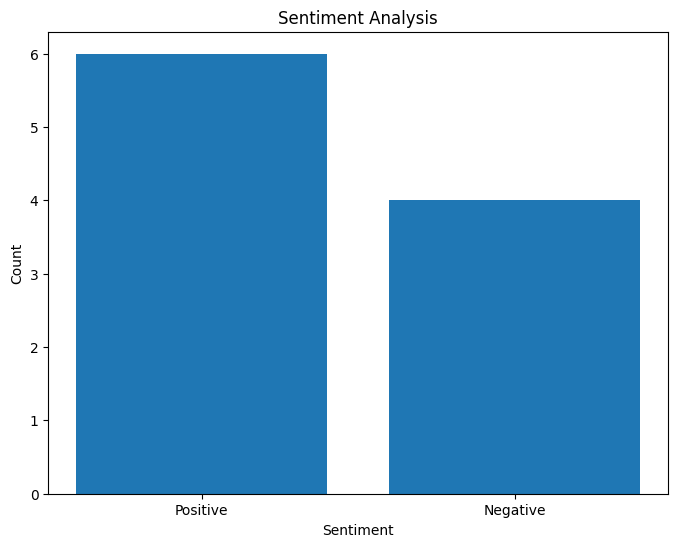

In [24]:
from matplotlib import figure
sentiment_counts = df['Sentiment'].value_counts()
plt.figure(figsize=(8, 6))
plt.bar(sentiment_counts.index, sentiment_counts.values)
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.title('Sentiment Analysis')
plt.show()

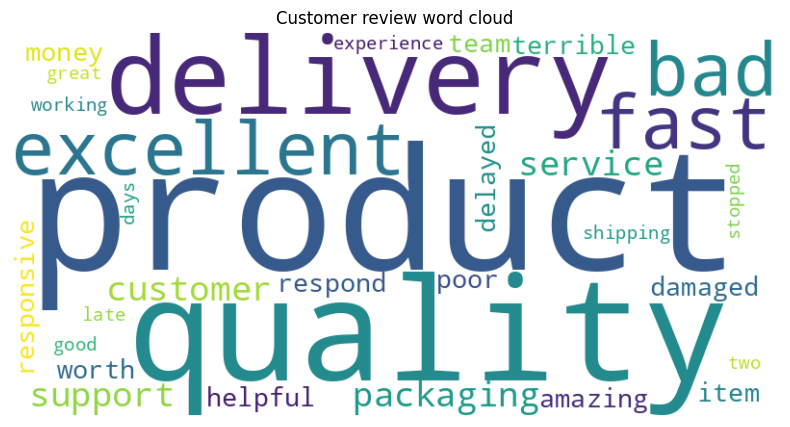

In [25]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Customer review word cloud')
plt.show()

In [30]:
print("\n Business Insights")
print("----------------------------------")

positive_count= len(df[df['Sentiment']=='Positive'])
negative_count=len(df[df['Sentiment']=='Negative'])
neutral_count=len(df[df['Sentiment']=='Neutral'])

print(f"Total positive reviews: {positive_count}")
print(f"Total negative reviews: {negative_count}")
print(f"Total neutral reviews: {neutral_count}")


print("\n Common postive areas")
print(" product quality")
print(" fast delivery")
print("good scustomer serivice")

print("\n common customer complaints")
print("Delayed delivery")
print('damaged products')



 Business Insights
----------------------------------
Total positive reviews: 6
Total negative reviews: 4
Total neutral reviews: 0

 Common postive areas
 product quality
 fast delivery
good scustomer serivice

 common customer complaints
Delayed delivery
damaged products
